In [11]:
import pandas as pd
import random
import yaml

In [12]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)
PARQUET_FILE = config['data']['parquet_file']

In [49]:
# Load the parquet file
df = pd.read_parquet(PARQUET_FILE)
test_df = df[df['split'] == 'test']
videos_test = test_df['video_name'].unique()
train_df = df[df['split'] == 'train']
videos_train = train_df['video_name'].unique()
val_df = df[df['split'] == 'val']
videos_val = val_df['video_name'].unique()
print(f"Unique videos in test set: {len(videos_test)}")
print(f"Unique videos in train set: {len(videos_train)}")
print(f"Unique videos in validation set: {len(videos_val)}")

df['first_five_names'] = df['video_name'].apply(lambda x: ''.join(list(x)[:6]))
vals = df['first_five_names'].unique()
print(f"Unique first five names: {len(vals)}")
print(vals)

Unique videos in test set: 20
Unique videos in train set: 61
Unique videos in validation set: 19
Unique first five names: 5
<ArrowStringArray>
['MVI_40', 'MVI_39', 'MVI_63', 'MVI_20', 'MVI_41']
Length: 5, dtype: str


In [51]:
# Select a random video from each prefix group
random_videos = []
for prefix in vals:
    group = df[df['first_five_names'] == prefix]
    video_name = random.choice(group['video_name'].unique())
    random_videos.append(video_name)
    video_name = random.choice(group['video_name'].unique())
    random_videos.append(video_name)
print("Randomly selected videos:")
for video in random_videos:
    print(video)

Randomly selected videos:
MVI_40192
MVI_40772
MVI_39801
MVI_39311
MVI_63554
MVI_63563
MVI_20064
MVI_20061
MVI_41073
MVI_41063


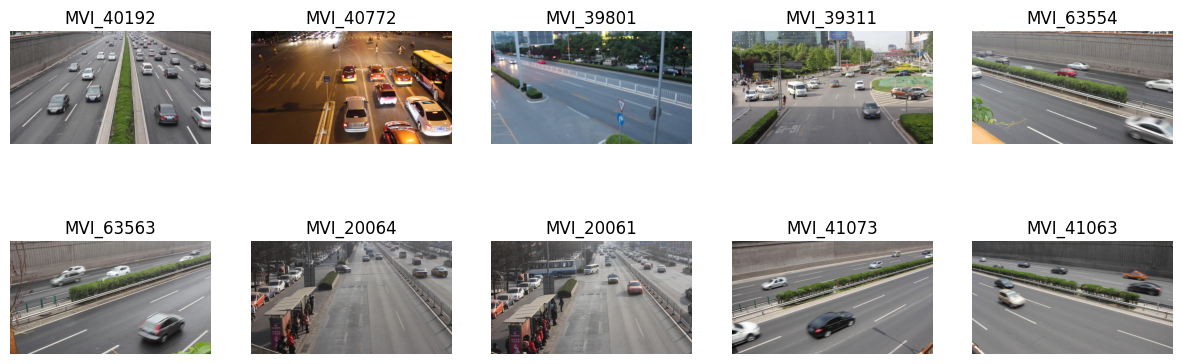

In [55]:
import os
import glob
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(2, len(random_videos)//2, figsize=(15, 5))
for i, video in enumerate(random_videos):
    frames_folder = config['data']['frames_folder']
    pattern = os.path.join(frames_folder, f"{video}_img*.jpg")
    frame_files = sorted(glob.glob(pattern))
    if not frame_files:
        print(f"No frames found for video: {video}")
        continue
    first_frame = cv2.imread(frame_files[0])
    first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    ax = axes[i // (len(random_videos)//2), i % (len(random_videos)//2)]
    ax.imshow(first_frame_rgb)
    ax.set_title(video)
    ax.axis('off')
plt.show()